In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain.messages import RemoveMessage

C:\Users\manoj\PycharmProjects\LangGraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()

model = ChatGoogleGenerativeAI(model='gemini-3-flash-preview')

In [3]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [4]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [5]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [6]:
graph = builder.compile(checkpointer=InMemorySaver())

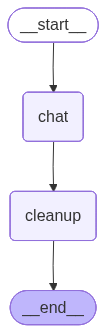

In [7]:
graph

In [1]:
config = {"configurable": {"thread_id": "t1"}}

In [9]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Manoj"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='826cb1a6-6852-4af1-ae65-9b1e88a01b2a'),
  AIMessage(content=[{'type': 'text', 'text': 'That is a great question to circle back to, Manoj. Since we already talked about **LangGraph**, understanding **LangChain** will make everything click into place.\n\nThink of it this way: \n*   **The LLM (like GPT-4)** is the **"Brain."** It’s smart, but it’s just a model.\n*   **LangChain** is the **"Body."** It provides the hands, eyes, and tools so the brain can actually do useful work in the real world.\n\n---\n\n### 1. What is LangChain?\n**LangChain** is an open-source framework designed to help developers build applications powered by Large Language Models (LLMs). \n\nOn its own, an LLM is "stateless" (it forgets everything once the chat ends) and "isolated" (it can\'t browse your files or use your database). LangChain provides the "glue" to connect LLMs to your data and other software.\n\n#

In [2]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

NameError: name 'graph' is not defined